# 11 · Real Data Pipeline
## Download · Clean · Calibrate · Export

**Goal:** Replace synthetic data with real Binance aggTrades, calibrate Guéant (2017)
parameters (σ, A, k) on actual order flow, and produce ready-to-use files for the
Streamlit dashboard.

| Step | What | Output |
|------|------|--------|
| 1 | Download aggTrades from `data.binance.vision` | Raw CSVs |
| 2 | Compute 1-second VWAP mid-prices | `mid_prices_{sym}.parquet` |
| 3 | Estimate σ (volatility per √s) | Per-day + aggregate |
| 4 | Fit Λ(δ) = A·exp(−kδ) (intensity) | A, k, R² |
| 5 | Cross-asset correlation | ρ(BTC, ETH) |
| 6 | Export calibrated params | `calibrated_params.json` |

**Data source:** [data.binance.vision](https://data.binance.vision/) — public, no API key,
aggregated trades (aggTrades) at tick resolution.

**Memory note:** BTC aggTrades ≈ 1–3M trades/day. We process **day-by-day** and accumulate
statistics incrementally — never loading the full dataset at once.

**Smart-skip:** If `calibrated_params.json` and `mid_prices_{sym}.parquet` already exist for
all symbols, the download and processing sections are **skipped entirely**. Results are loaded
directly from disk. Re-run with `FORCE_RERUN = True` to redo calibration.

In [1]:
import io, os, sys, zipfile, json, pickle, time, warnings
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import curve_fit

warnings.filterwarnings("ignore", category=FutureWarning)

# ── Configuration ────────────────────────────────────────────
SYMBOLS   = ["BTCUSDT"]          # add "ETHUSDT" if desired
N_DAYS    = 90                   # days of history
END_DATE  = "2025-06-03"         # last day to include
RAW_DIR   = Path("data/raw")
OUT_DIR   = Path("data/calibrated")
FREQ      = "1s"                 # mid-price sampling frequency
FORCE_RERUN = False              # set True to ignore existing outputs

_end = datetime.strptime(END_DATE, "%Y-%m-%d")
START_DATE = (_end - timedelta(days=N_DAYS - 1)).strftime("%Y-%m-%d")

RAW_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Pipeline: {', '.join(SYMBOLS)}")
print(f"Period:   {START_DATE} → {END_DATE} ({N_DAYS} days)")
print(f"Raw dir:  {RAW_DIR.resolve()}")
print(f"Out dir:  {OUT_DIR.resolve()}")

Pipeline: BTCUSDT
Period:   2025-03-06 → 2025-06-03 (90 days)
Raw dir:  /Users/hamzaelarji/Desktop/All/Bureau/cours/Imperial College/Term 2/Elective modules/Chosen Elective Modules /Market Microstructure/Coursework/Market-Microstructure-/project/data/data/raw
Out dir:  /Users/hamzaelarji/Desktop/All/Bureau/cours/Imperial College/Term 2/Elective modules/Chosen Elective Modules /Market Microstructure/Coursework/Market-Microstructure-/project/data/data/calibrated


In [2]:
# ── Check if final outputs already exist ─────────────────────
def _outputs_complete(symbols, out_dir):
    if not (out_dir / "calibrated_params.json").exists():
        return False
    return all((out_dir / f"mid_prices_{s}.parquet").exists() for s in symbols)

PIPELINE_DONE = _outputs_complete(SYMBOLS, OUT_DIR) and not FORCE_RERUN

if PIPELINE_DONE:
    print("✅ All outputs found — download & processing will be SKIPPED.")
    print(f"   {OUT_DIR / 'calibrated_params.json'}")
    for sym in SYMBOLS:
        pq = OUT_DIR / f"mid_prices_{sym}.parquet"
        mb = pq.stat().st_size / 1e6
        print(f"   {pq}  ({mb:.1f} MB)")
    print()
    print("   Set FORCE_RERUN = True to redo calibration from scratch.")
else:
    missing = []
    if not (OUT_DIR / "calibrated_params.json").exists():
        missing.append("calibrated_params.json")
    for sym in SYMBOLS:
        if not (OUT_DIR / f"mid_prices_{sym}.parquet").exists():
            missing.append(f"mid_prices_{sym}.parquet")
    print(f"⚙️  Missing outputs: {', '.join(missing)}")
    print("   Full pipeline will run.")

✅ All outputs found — download & processing will be SKIPPED.
   data/calibrated/calibrated_params.json
   data/calibrated/mid_prices_BTCUSDT.parquet  (95.4 MB)

   Set FORCE_RERUN = True to redo calibration from scratch.


In [3]:
# ── Early load: restore calibrated + mid_series from disk ────
# Runs always; populates data structures used by later cells.
calibrated  = {}
mid_series  = {}
pipeline_results = {}   # populated by processing loop OR checkpoint

CKPT_DIR = OUT_DIR / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

if PIPELINE_DONE:
    # ── Load calibrated params ───────────────────────────────
    with open(OUT_DIR / "calibrated_params.json") as f:
        raw_params = json.load(f)
    for sym in SYMBOLS:
        if sym in raw_params:
            calibrated[sym] = dict(raw_params[sym])
    if "cross_correlation" in raw_params:
        rho_val = raw_params["cross_correlation"].get("rho")
        if rho_val is not None:
            calibrated["rho"] = rho_val

    # ── Load mid-price parquets ──────────────────────────────
    for sym in SYMBOLS:
        pq = OUT_DIR / f"mid_prices_{sym}.parquet"
        if pq.exists():
            mid_series[sym] = pd.read_parquet(pq)["mid_price"]
            print(f"  {sym}: {len(mid_series[sym]):,} mid-price points loaded")

    # ── Try to load checkpoint (for Appendix B per-day deltas) ─
    for sym in SYMBOLS:
        ckpt_path = CKPT_DIR / f"{sym}_checkpoint.pkl"
        if ckpt_path.exists():
            try:
                with open(ckpt_path, "rb") as f:
                    ckpt = pickle.load(f)
                pipeline_results[sym] = {k: ckpt[k] for k in
                    ("all_mid","all_returns","all_deltas","daily_sigma","daily_stats",
                     "total_seconds","total_trades")}
                n = len(ckpt["processed_files"])
                print(f"  {sym}: checkpoint loaded ({n} days — available for Appendix B)")
            except Exception as e:
                print(f"  {sym}: checkpoint unreadable ({e}) — Appendix B will be skipped")

    print()
    print(f"  Period:  {raw_params.get(SYMBOLS[0],{}).get('period','N/A')}")
    print(f"  Calib:   {raw_params.get(SYMBOLS[0],{}).get('calibration_date','N/A')}")
    print()
    print("✅ Ready — scroll to §9 (Validation) or Appendices for results.")

  BTCUSDT: 7,309,820 mid-price points loaded
  BTCUSDT: checkpoint loaded (1080 days — available for Appendix B)

  Period:  2025-03-04 → 2025-06-01
  Calib:   2026-03-04 15:20

✅ Ready — scroll to §9 (Validation) or Appendices for results.


## 1 · Download aggTrades

Each daily file is a ZIP containing one CSV with columns:
`agg_trade_id, price, quantity, first_trade_id, last_trade_id, transact_time, is_buyer_maker`

Typical sizes: **BTC ≈ 50–150 MB/day** (compressed).

> If `PIPELINE_DONE = True`, the cells below are no-ops — data already on disk.

In [4]:
import requests

BASE_URL = "https://data.binance.vision/data/spot/daily/aggTrades"
AGGTRADE_COLS = [
    "agg_trade_id", "price", "quantity",
    "first_trade_id", "last_trade_id",
    "transact_time", "is_buyer_maker",
    "ignore",
]


def download_day(symbol: str, date_str: str, out_dir: Path) -> Path | None:
    fname    = f"{symbol}-aggTrades-{date_str}"
    csv_path = out_dir / f"{fname}.csv"
    if csv_path.exists():
        return csv_path
    url = f"{BASE_URL}/{symbol}/{fname}.zip"
    try:
        resp = requests.get(url, timeout=60)
        if resp.status_code != 200:
            return None
    except requests.RequestException:
        return None
    try:
        with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
            csv_name = [n for n in zf.namelist() if n.endswith(".csv")][0]
            zf.extract(csv_name, out_dir)
            extracted = out_dir / csv_name
            if extracted != csv_path:
                extracted.rename(csv_path)
    except Exception:
        return None
    return csv_path


def load_day(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path, header=None, names=AGGTRADE_COLS)
    df["transact_time"] = pd.to_numeric(df["transact_time"], errors="coerce")
    df["timestamp"]     = pd.to_datetime(df["transact_time"], unit="us", errors="coerce")
    df["price"]         = pd.to_numeric(df["price"],    errors="coerce")
    df["quantity"]      = pd.to_numeric(df["quantity"], errors="coerce")
    df["is_buyer_maker"] = (df["is_buyer_maker"].astype(str)
                            .str.lower().map({"true": True, "false": False}))
    df = df.dropna(subset=["timestamp", "price", "quantity", "is_buyer_maker"])
    return df[["timestamp", "price", "quantity", "is_buyer_maker"]]


print("Download functions ready.")

Download functions ready.


In [5]:
if PIPELINE_DONE:
    print("⏭️  Skipping download — all outputs already exist.")
else:
    download_report = {}
    for symbol in SYMBOLS:
        sym_dir = RAW_DIR / symbol
        sym_dir.mkdir(parents=True, exist_ok=True)

        d     = datetime.strptime(START_DATE, "%Y-%m-%d")
        d_end = datetime.strptime(END_DATE,   "%Y-%m-%d")
        total = (d_end - d).days + 1
        ok, fail = 0, 0

        print(f"\n{'='*60}")
        print(f"Downloading {symbol} ({total} days)")
        print(f"{'='*60}")

        while d <= d_end:
            date_str = d.strftime("%Y-%m-%d")
            day_num  = (d - datetime.strptime(START_DATE, "%Y-%m-%d")).days + 1
            print(f"  [{day_num:3d}/{total}] {date_str} ... ", end="", flush=True)

            p = download_day(symbol, date_str, sym_dir)
            if p is not None:
                print(f"OK ({p.stat().st_size/1e6:.1f} MB)")
                ok += 1
            else:
                print("SKIP")
                fail += 1
            d += timedelta(days=1)

        download_report[symbol] = {"ok": ok, "fail": fail, "total": total}
        print(f"\n  Result: {ok}/{total} days downloaded, {fail} missing")

    print("\n" + "="*60)
    for sym, r in download_report.items():
        print(f"  {sym}: {r['ok']}/{r['total']} days")

⏭️  Skipping download — all outputs already exist.


## 2 · Quick Look — One Day of Raw Data

Before processing all days, inspect a single day to understand the data.
*(Skipped if outputs already exist.)*

In [6]:
if PIPELINE_DONE:
    print("⏭️  Skipping quick look.")
else:
    sample_data = {}
    for symbol in SYMBOLS:
        sym_dir = RAW_DIR / symbol
        csvs = sorted(sym_dir.glob("*.csv"))
        if not csvs:
            print(f"  {symbol}: no data found — run download first!")
            continue
        df = load_day(csvs[len(csvs)//2])
        sample_data[symbol] = df
        print(f"\n{'='*50}")
        print(f"{symbol} — sample day")
        print(f"{'='*50}")
        print(f"  Trades:     {len(df):>12,}")
        print(f"  Time span:  {df['timestamp'].min()} → {df['timestamp'].max()}")
        print(f"  Price range:{df['price'].min():>12,.2f} → {df['price'].max():>12,.2f}")
        print(f"  Mean qty:   {df['quantity'].mean():>12.6f}")
        print(f"  Buy ratio:  {(~df['is_buyer_maker']).mean():>12.1%}")
        display(df.head(10))

⏭️  Skipping quick look.


In [7]:
if PIPELINE_DONE or not sample_data:
    if PIPELINE_DONE:
        print("⏭️  Skipping quick look plots.")
else:
    fig, axes = plt.subplots(len(sample_data), 3,
                             figsize=(18, 5*len(sample_data)))
    if len(sample_data) == 1:
        axes = axes[np.newaxis, :]

    for row, (symbol, df) in enumerate(sample_data.items()):
        ax = axes[row, 0]
        ax.plot(df["timestamp"], df["price"], lw=0.3, alpha=0.7)
        ax.set_title(f"{symbol} — Price", fontsize=12, fontweight="bold")
        ax.set_ylabel("Price (USDT)")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

        ax = axes[row, 1]
        trades_per_min = df.set_index("timestamp").resample("1min").size()
        ax.bar(trades_per_min.index, trades_per_min.values, width=1/1440, alpha=0.7)
        ax.set_title(f"{symbol} — Trade Frequency", fontsize=12, fontweight="bold")
        ax.set_ylabel("Trades / minute")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

        ax = axes[row, 2]
        q99 = df["quantity"].quantile(0.99)
        ax.hist(df["quantity"][df["quantity"] < q99], bins=100, alpha=0.7)
        ax.set_title(f"{symbol} — Trade Size Distribution", fontsize=12, fontweight="bold")
        ax.set_xlabel("Quantity"); ax.set_ylabel("Count")
        med = df["quantity"].median()
        ax.axvline(med, color="red", ls="--", label=f"median={med:.4f}")
        ax.legend()

    plt.tight_layout()
    plt.savefig(str(OUT_DIR / "sample_day_overview.png"), dpi=150, bbox_inches="tight")
    plt.show()

⏭️  Skipping quick look plots.


## 3 · Incremental Processing — All Days

Process each day independently (bounded memory):
1. Load daily CSV → compute 1-second VWAP mid-price
2. Compute daily returns → accumulate for σ estimation
3. Compute trade-vs-mid deltas → accumulate for intensity fitting

Checkpointing every 5 days — safe to interrupt and resume.
*(Skipped if outputs already exist.)*

In [8]:
# ── Checkpoint helpers ───────────────────────────────────────
def save_checkpoint(symbol: str, state: dict) -> Path:
    ckpt_path = CKPT_DIR / f"{symbol}_checkpoint.pkl"
    tmp_path  = CKPT_DIR / f"{symbol}_checkpoint.tmp"
    with open(tmp_path, "wb") as f:
        pickle.dump(state, f)
    tmp_path.replace(ckpt_path)
    return ckpt_path


def load_checkpoint(symbol: str) -> dict | None:
    ckpt_path = CKPT_DIR / f"{symbol}_checkpoint.pkl"
    if not ckpt_path.exists():
        return None
    try:
        with open(ckpt_path, "rb") as f:
            return pickle.load(f)
    except Exception as e:
        print(f"  ⚠️ Checkpoint corrupt ({e}), removing...")
        ckpt_path.unlink()
        return None


def compute_mid_price(trades: pd.DataFrame, freq: str = "1s") -> pd.Series:
    t       = trades.set_index("timestamp")
    notional = (t["price"] * t["quantity"]).resample(freq).sum()
    volume   = t["quantity"].resample(freq).sum()
    mid      = (notional / volume).dropna()
    mid.name = "mid_price"
    return mid


def compute_deltas(trades: pd.DataFrame, mid: pd.Series) -> np.ndarray:
    t = trades.set_index("timestamp").copy()
    t["mid"] = mid.reindex(t.index, method="ffill")
    t = t.dropna(subset=["mid"])
    return np.abs(t["price"].values - t["mid"].values)


print("Processing functions defined.")

Processing functions defined.


In [9]:
SAVE_EVERY = 5

if PIPELINE_DONE:
    print("⏭️  Skipping processing — all outputs already exist.")
else:
    for symbol in SYMBOLS:
        sym_dir = RAW_DIR / symbol
        csvs = sorted(sym_dir.glob(f"{symbol}-aggTrades-*.csv"))
        n_days = len(csvs)

        if n_days == 0:
            print(f"  {symbol}: no CSVs found — run download first!")
            continue

        print(f"\n{'='*60}")
        print(f"Processing {symbol} ({n_days} days)")
        print(f"{'='*60}")

        ckpt = load_checkpoint(symbol)
        if ckpt is not None:
            print(f"  ↻ Resuming from checkpoint ({len(ckpt['processed_files'])} days done)")
            all_mid        = ckpt["all_mid"]
            all_returns    = ckpt["all_returns"]
            all_deltas     = ckpt["all_deltas"]
            daily_sigma    = ckpt["daily_sigma"]
            daily_stats    = ckpt["daily_stats"]
            total_seconds  = ckpt["total_seconds"]
            total_trades   = ckpt["total_trades"]
            processed_files = set(ckpt["processed_files"])
        else:
            all_mid = []; all_returns = []; all_deltas = []
            daily_sigma = []; daily_stats = []
            total_seconds = 0.0; total_trades = 0
            processed_files = set()

        for i, csv_path in enumerate(csvs):
            csv_key   = csv_path.name
            day_label = csv_path.stem.split("aggTrades-")[-1]

            if csv_key in processed_files:
                print(f"  [{i+1:3d}/{n_days}] {day_label} ... SKIP (checkpoint)")
                continue

            print(f"  [{i+1:3d}/{n_days}] {day_label} ... ", end="", flush=True)
            try:
                df = load_day(csv_path)
                n_trades = len(df)
                total_trades += n_trades

                mid     = compute_mid_price(df, freq=FREQ)
                all_mid.append(mid)

                returns = mid.diff().dropna().values
                all_returns.append(returns)

                sig_day = float(np.std(returns))
                daily_sigma.append(sig_day)

                deltas = compute_deltas(df, mid)
                all_deltas.append(deltas)

                span = (df["timestamp"].max() - df["timestamp"].min()).total_seconds()
                total_seconds += span

                daily_stats.append({
                    "date": day_label, "n_trades": n_trades,
                    "mean_price": float(df["price"].mean()),
                    "sigma": sig_day, "span_hours": span / 3600,
                })
                processed_files.add(csv_key)
                print(f"OK ({n_trades:>8,} trades, σ={sig_day:.4f})")

                if len(processed_files) % SAVE_EVERY == 0:
                    state = dict(all_mid=all_mid, all_returns=all_returns,
                                 all_deltas=all_deltas, daily_sigma=daily_sigma,
                                 daily_stats=daily_stats, total_seconds=total_seconds,
                                 total_trades=total_trades,
                                 processed_files=sorted(processed_files))
                    p = save_checkpoint(symbol, state)
                    print(f"    💾 checkpoint: {p.name}")

            except Exception as e:
                print(f"ERROR: {e}")
                continue

        # final checkpoint + store results
        state = dict(all_mid=all_mid, all_returns=all_returns,
                     all_deltas=all_deltas, daily_sigma=daily_sigma,
                     daily_stats=daily_stats, total_seconds=total_seconds,
                     total_trades=total_trades,
                     processed_files=sorted(processed_files))
        save_checkpoint(symbol, state)

        pipeline_results[symbol] = {k: state[k] for k in
            ("all_mid","all_returns","all_deltas","daily_sigma","daily_stats",
             "total_seconds","total_trades")}
        print(f"\n  Total: {total_trades:,} trades over {total_seconds/3600:.0f} h")

⏭️  Skipping processing — all outputs already exist.


## 4 · Volatility Estimation — σ ($/√s)

$$\sigma = \frac{\text{Std}(\Delta S)}{\sqrt{\Delta t}}, \quad \Delta t = 1\text{s}$$

*(Skipped if outputs already exist.)*

In [10]:
if PIPELINE_DONE:
    print("⏭️  Skipping σ plots — load calibrated_params.json for values.")
    for sym in SYMBOLS:
        if sym in calibrated:
            print(f"  {sym}: σ = {calibrated[sym].get('sigma', 'N/A'):.6f} $/√s")
else:
    fig, axes = plt.subplots(1, len(SYMBOLS), figsize=(8*len(SYMBOLS), 5))
    if len(SYMBOLS) == 1:
        axes = [axes]

    for ax, symbol in zip(axes, SYMBOLS):
        res = pipeline_results[symbol]
        all_ret   = np.concatenate(res["all_returns"])
        sigma_agg = float(np.std(all_ret))
        daily_sig = np.array(res["daily_sigma"])

        calibrated.setdefault(symbol, {})["sigma"] = sigma_agg

        ax.plot(range(len(daily_sig)), daily_sig, "o-", ms=3, alpha=0.7)
        ax.axhline(sigma_agg, color="red", ls="--", lw=2,
                   label=f"Aggregate σ = {sigma_agg:.4f}")
        ax.axhline(np.median(daily_sig), color="green", ls=":", lw=1.5,
                   label=f"Median σ = {np.median(daily_sig):.4f}")
        ax.fill_between(range(len(daily_sig)),
                        np.percentile(daily_sig, 10), np.percentile(daily_sig, 90),
                        alpha=0.15, color="blue", label="P10–P90")
        ax.set_title(f"{symbol} — Daily σ ($/√s)", fontsize=13, fontweight="bold")
        ax.set_xlabel("Day index"); ax.set_ylabel("σ ($/√s)")
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
        print(f"  {symbol}: σ_aggregate = {sigma_agg:.6f}  "
              f"range=[{daily_sig.min():.6f}, {daily_sig.max():.6f}]")

    plt.tight_layout()
    plt.savefig(str(OUT_DIR / "sigma_daily.png"), dpi=150, bbox_inches="tight")
    plt.show()

⏭️  Skipping σ plots — load calibrated_params.json for values.
  BTCUSDT: σ = 5.756427 $/√s


In [11]:
if PIPELINE_DONE:
    pass  # already shown above
else:
    fig, axes = plt.subplots(1, len(SYMBOLS), figsize=(8*len(SYMBOLS), 5))
    if len(SYMBOLS) == 1:
        axes = [axes]

    for ax, symbol in zip(axes, SYMBOLS):
        all_ret = np.concatenate(pipeline_results[symbol]["all_returns"])
        q01, q99 = np.percentile(all_ret, [0.5, 99.5])
        trimmed  = all_ret[(all_ret > q01) & (all_ret < q99)]

        ax.hist(trimmed, bins=200, density=True, alpha=0.7, label="Empirical")
        sigma = calibrated[symbol]["sigma"]
        x_g = np.linspace(q01, q99, 300)
        ax.plot(x_g, np.exp(-x_g**2/(2*sigma**2))/(sigma*np.sqrt(2*np.pi)),
                "r-", lw=2, label=f"Gaussian σ={sigma:.4f}")
        ax.set_title(f"{symbol} — 1s Return Distribution", fontsize=13, fontweight="bold")
        ax.set_xlabel("ΔS ($/s)"); ax.set_ylabel("Density")
        ax.legend(); ax.grid(True, alpha=0.3)
        kurt = float(pd.Series(all_ret).kurtosis())
        print(f"  {symbol}: kurtosis = {kurt:.2f} (Gaussian = 0)")

    plt.tight_layout()
    plt.savefig(str(OUT_DIR / "returns_distribution.png"), dpi=150, bbox_inches="tight")
    plt.show()

## 5 · Intensity Calibration — Λ(δ) = A·exp(−kδ)

$$\Lambda(\delta) = A \cdot e^{-k\delta}$$

*(Skipped if outputs already exist.)*

In [12]:
def fit_intensity(deltas: np.ndarray, total_seconds: float,
                  n_bins: int = 50, max_quantile: float = 0.95):
    """Fit Λ(δ) = A·exp(-kδ). Returns (A, k, R², centers, λ_obs, λ_fit)."""
    deltas_pos = deltas[deltas > 0]
    max_delta  = np.quantile(deltas_pos, max_quantile)
    bins       = np.linspace(0, max_delta, n_bins + 1)
    centers    = 0.5 * (bins[:-1] + bins[1:])

    counts     = np.histogram(deltas_pos, bins=bins)[0]
    lam_obs    = counts / total_seconds

    mask = lam_obs > 0
    if mask.sum() < 3:
        raise ValueError("Not enough non-empty bins")
    x_fit, y_fit = centers[mask], lam_obs[mask]

    def exp_model(d, A, k):
        return A * np.exp(-k * d)

    popt, _ = curve_fit(exp_model, x_fit, y_fit,
                        p0=[y_fit[0], 1.0/(max_delta*0.3)],
                        bounds=([0,0],[np.inf,np.inf]), maxfev=10000)
    A_fit, k_fit = popt

    y_pred = exp_model(x_fit, A_fit, k_fit)
    ss_res = np.sum((y_fit - y_pred)**2)
    ss_tot = np.sum((y_fit - np.mean(y_fit))**2)
    r_sq   = 1.0 - ss_res/ss_tot if ss_tot > 0 else 0.0

    return A_fit, k_fit, r_sq, centers, lam_obs, exp_model(centers, A_fit, k_fit)


print("fit_intensity defined.")

fit_intensity defined.


In [13]:
if PIPELINE_DONE:
    print("⏭️  Skipping intensity fit — values loaded from calibrated_params.json.")
    for sym in SYMBOLS:
        if sym in calibrated:
            p = calibrated[sym]
            print(f"  {sym}: A={p.get('A','?'):.6g}, k={p.get('k','?'):.6g}, "
                  f"R²={p.get('r_squared','?'):.4f}")
else:
    fig, axes = plt.subplots(1, len(SYMBOLS), figsize=(8*len(SYMBOLS), 6))
    if len(SYMBOLS) == 1:
        axes = [axes]

    for ax, symbol in zip(axes, SYMBOLS):
        res = pipeline_results[symbol]
        all_deltas = np.concatenate(res["all_deltas"])
        A, k, r_sq, centers, lam_obs, lam_fit = fit_intensity(
            all_deltas, res["total_seconds"], n_bins=50)

        calibrated[symbol]["A"]         = A
        calibrated[symbol]["k"]         = k
        calibrated[symbol]["r_squared"] = r_sq

        ax.semilogy(centers, lam_obs, "o", ms=4, alpha=0.6, label="Empirical Λ(δ)")
        ax.semilogy(centers, lam_fit,  "r-", lw=2,
                    label=f"Fit: A={A:.4f}, k={k:.4f}\nR²={r_sq:.4f}")
        ax.set_title(f"{symbol} — Intensity Λ(δ) = A·exp(−kδ)",
                     fontsize=13, fontweight="bold")
        ax.set_xlabel("δ (USDT)"); ax.set_ylabel("Λ(δ) (trades/s)")
        ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
        print(f"  {symbol}: A={A:.6f}, k={k:.6f}, R²={r_sq:.4f}")

    plt.tight_layout()
    plt.savefig(str(OUT_DIR / "intensity_fit.png"), dpi=150, bbox_inches="tight")
    plt.show()

⏭️  Skipping intensity fit — values loaded from calibrated_params.json.
  BTCUSDT: A=5.5462, k=2.73308, R²=0.7787


In [14]:
if PIPELINE_DONE:
    pass
else:
    fig, axes = plt.subplots(len(SYMBOLS), 2, figsize=(14, 5*len(SYMBOLS)))
    if len(SYMBOLS) == 1:
        axes = axes[np.newaxis, :]

    for row, symbol in enumerate(SYMBOLS):
        res = pipeline_results[symbol]
        all_deltas = np.concatenate(res["all_deltas"])
        A, k = calibrated[symbol]["A"], calibrated[symbol]["k"]

        deltas_pos = all_deltas[all_deltas > 0]
        max_delta  = np.quantile(deltas_pos, 0.95)
        bins       = np.linspace(0, max_delta, 51)
        centers    = 0.5*(bins[:-1]+bins[1:])
        lam_obs    = np.histogram(deltas_pos, bins=bins)[0] / res["total_seconds"]
        lam_fit    = A * np.exp(-k * centers)

        mask = lam_obs > 0
        rel  = (lam_obs[mask] - lam_fit[mask]) / lam_fit[mask]

        ax = axes[row, 0]
        ax.bar(centers[mask], rel*100, width=centers[1]-centers[0], alpha=0.6)
        ax.axhline(0, color="red"); ax.grid(True, alpha=0.3)
        ax.set_title(f"{symbol} — Relative Residuals (%)"); ax.set_xlabel("δ (USDT)")

        ax = axes[row, 1]
        ax.scatter(lam_fit[mask], lam_obs[mask], s=20, alpha=0.6)
        lim = [0, max(lam_obs[mask].max(), lam_fit[mask].max())*1.1]
        ax.plot(lim, lim, "r--", lw=1.5, label="Perfect fit")
        ax.set_title(f"{symbol} — Observed vs Fitted")
        ax.set_xlabel("Λ_fit"); ax.set_ylabel("Λ_obs")
        ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(str(OUT_DIR / "intensity_residuals.png"), dpi=150, bbox_inches="tight")
    plt.show()

## 6 · Mid-Price Series & Cross-Asset Correlation

*(Skipped if outputs already exist — mid_series loaded from parquet.)*

In [15]:
if PIPELINE_DONE:
    print("⏭️  mid_series already loaded from parquet files.")
    if len(mid_series) == 2:
        sym1, sym2 = SYMBOLS
        m1, m2 = mid_series[sym1], mid_series[sym2]
        common = m1.index.intersection(m2.index)
        if len(common) > 100:
            r1 = m1.reindex(common).diff().dropna()
            r2 = m2.reindex(common).diff().dropna()
            c  = r1.index.intersection(r2.index)
            rho = float(np.corrcoef(r1.loc[c], r2.loc[c])[0,1])
            print(f"  ρ({sym1}, {sym2}) = {rho:.4f}")
else:
    for symbol in SYMBOLS:
        mids = pipeline_results[symbol]["all_mid"]
        if mids:
            full = pd.concat(mids).sort_index()
            full = full[~full.index.duplicated(keep="first")]
            mid_series[symbol] = full
            print(f"  {symbol}: {len(full):,} mid-price points "
                  f"({full.index.min()} → {full.index.max()})")

    if len(mid_series) == 2:
        sym1, sym2 = SYMBOLS
        m1, m2 = mid_series[sym1], mid_series[sym2]
        common = m1.index.intersection(m2.index)
        print(f"\n  Common timestamps: {len(common):,}")
        if len(common) > 100:
            r1 = m1.reindex(common).diff().dropna()
            r2 = m2.reindex(common).diff().dropna()
            c  = r1.index.intersection(r2.index)
            rho = float(np.corrcoef(r1.loc[c], r2.loc[c])[0,1])
            print(f"  ρ({sym1}, {sym2}) = {rho:.4f}")
            calibrated["rho"] = rho
        else:
            calibrated["rho"] = None

⏭️  mid_series already loaded from parquet files.


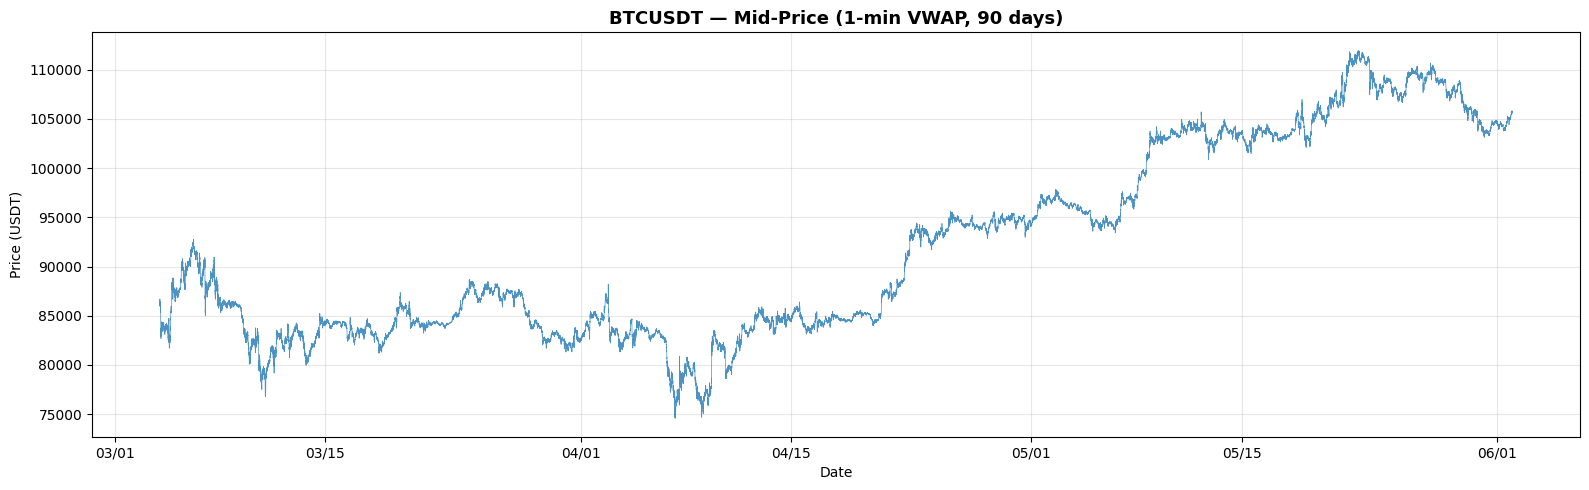

In [16]:
fig, axes = plt.subplots(len(SYMBOLS), 1,
                        figsize=(16, 5*len(SYMBOLS)), sharex=True)
if len(SYMBOLS) == 1:
    axes = [axes]

for ax, symbol in zip(axes, SYMBOLS):
    if symbol not in mid_series:
        ax.text(0.5, 0.5, "No data", ha="center", va="center",
                transform=ax.transAxes)
        continue
    mid = mid_series[symbol]
    mid_plot = mid.resample("1min").mean().dropna()
    ax.plot(mid_plot.index, mid_plot.values, lw=0.5, alpha=0.8)
    ax.set_title(f"{symbol} — Mid-Price (1-min VWAP, {N_DAYS} days)",
                 fontsize=13, fontweight="bold")
    ax.set_ylabel("Price (USDT)"); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))

plt.xlabel("Date"); plt.tight_layout()
plt.savefig(str(OUT_DIR / "mid_price_full.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7 · Parameter Summary & Δ Estimation

*(Skipped if outputs already exist.)*

In [17]:
LOT_SIZES = {"BTCUSDT": 0.001, "ETHUSDT": 0.01}
Q_MAX     = 4

if PIPELINE_DONE:
    print("⏭️  Parameters already in calibrated dict (loaded from JSON).")
    for sym in SYMBOLS:
        if sym in calibrated:
            p = calibrated[sym]
            print(f"  {sym}: σ={p.get('sigma',0):.6f}, A={p.get('A',0):.4f}, "
                  f"k={p.get('k',0):.6f}, Δ={p.get('Delta',0):.2f}")
else:
    summary_rows = []
    for symbol in SYMBOLS:
        if symbol not in calibrated:
            continue
        res        = pipeline_results[symbol]
        mean_price = np.mean([s["mean_price"] for s in res["daily_stats"]])
        lot_size   = LOT_SIZES.get(symbol, 0.001)
        Delta      = mean_price * lot_size

        calibrated[symbol].update({
            "Delta": round(Delta, 2), "Q": Q_MAX,
            "mean_price": round(mean_price, 2), "lot_size": lot_size,
            "n_trades": res["total_trades"], "n_days": len(res["daily_stats"]),
            "total_hours": round(res["total_seconds"]/3600, 1),
        })

        summary_rows.append({
            "Symbol":       symbol,
            "σ ($/√s)":     f"{calibrated[symbol]['sigma']:.6f}",
            "A (1/s)":      f"{calibrated[symbol]['A']:.4f}",
            "k (1/$)":      f"{calibrated[symbol]['k']:.6f}",
            "R²":           f"{calibrated[symbol]['r_squared']:.4f}",
            "Δ ($)":        f"{Delta:.2f}",
            "Q":            Q_MAX,
            "Mean Price":   f"${mean_price:,.2f}",
            "Total Trades": f"{res['total_trades']:,}",
            "Days":         len(res["daily_stats"]),
        })

    display(pd.DataFrame(summary_rows))

⏭️  Parameters already in calibrated dict (loaded from JSON).
  BTCUSDT: σ=5.756427, A=5.5462, k=2.733083, Δ=91.86


In [18]:
GAMMA = 1e-6  # risk aversion (adjust for your strategy)

print(f"Derived Guéant quantities (γ = {GAMMA:.1e}):\n")
for symbol in SYMBOLS:
    if symbol not in calibrated:
        continue
    p = calibrated[symbol]
    sigma, A = p["sigma"], p["A"]
    k, Delta = p["k"], p["Delta"]

    xi_Delta = GAMMA * Delta
    if abs(xi_Delta) > 1e-12:
        d_static = (1.0/xi_Delta) * np.log(1.0 + xi_Delta/k)
        C = (xi_Delta/(1 + xi_Delta/k)) * (1/k)
    else:
        d_static = 1.0/k
        C = 1.0/k**2

    omega    = np.sqrt(GAMMA * sigma**2 / (2.0 * A * Delta * k * C))
    spread_0 = 2*d_static + omega*Delta

    print(f"  {symbol}:")
    print(f"    ξΔ        = {xi_Delta:.6f}")
    print(f"    δ_static  = {d_static:.6f} USDT")
    print(f"    ω (slope) = {omega:.6e}")
    print(f"    Spread(0) = {spread_0:.4f} USDT  "
          f"({spread_0/p.get('mean_price',1)*100:.4f}% of price)")
    print()

    calibrated[symbol].update({
        "gamma": GAMMA, "d_static": d_static,
        "omega": omega,  "spread_0": spread_0,
    })

Derived Guéant quantities (γ = 1.0e-06):

  BTCUSDT:
    ξΔ        = 0.000092
    δ_static  = 0.365881 USDT
    ω (slope) = 1.881573e-02
    Spread(0) = 2.4602 USDT  (0.0027% of price)



## 8 · Export Results

*(Skipped if outputs already exist.)*

In [19]:
if PIPELINE_DONE:
    print("⏭️  Skipping export — files already on disk.")
else:
    # ── 1. calibrated_params.json ────────────────────────────
    params_export = {}
    for symbol in SYMBOLS:
        if symbol not in calibrated:
            continue
        p = calibrated[symbol]
        params_export[symbol] = {
            "sigma":    round(p["sigma"], 8),
            "A":        round(p["A"], 8),
            "k":        round(p["k"], 8),
            "Delta":    round(p["Delta"], 2),
            "Q":        p["Q"],
            "mean_price":       p.get("mean_price", 0),
            "lot_size":         p.get("lot_size", 0),
            "r_squared":        round(p.get("r_squared", 0), 4),
            "n_trades":         p.get("n_trades", 0),
            "n_days":           p.get("n_days", 0),
            "total_hours":      p.get("total_hours", 0),
            "calibration_date": datetime.now().strftime("%Y-%m-%d %H:%M"),
            "source":           "data.binance.vision aggTrades",
            "period":           f"{START_DATE} → {END_DATE}",
        }

    if "rho" in calibrated and calibrated["rho"] is not None:
        params_export["cross_correlation"] = {
            "symbols": SYMBOLS, "rho": round(calibrated["rho"], 6),
        }

    json_path = OUT_DIR / "calibrated_params.json"
    with open(json_path, "w") as f:
        json.dump(params_export, f, indent=2)
    print(f"Saved: {json_path}")
    print(json.dumps(params_export, indent=2))

    # ── 2. mid_prices_{SYM}.parquet ─────────────────────────
    for symbol in SYMBOLS:
        if symbol in mid_series:
            pq_path = OUT_DIR / f"mid_prices_{symbol}.parquet"
            mid_series[symbol].to_frame("mid_price").to_parquet(pq_path)
            print(f"Saved: {pq_path}  ({pq_path.stat().st_size/1e6:.1f} MB, "
                  f"{len(mid_series[symbol]):,} rows)")

    # ── 3. daily_stats_{SYM}.csv ────────────────────────────
    for symbol in SYMBOLS:
        if symbol in pipeline_results:
            stats_df  = pd.DataFrame(pipeline_results[symbol]["daily_stats"])
            stats_path = OUT_DIR / f"daily_stats_{symbol}.csv"
            stats_df.to_csv(stats_path, index=False)
            print(f"Saved: {stats_path}")

    print("\n✅ Export complete!")

⏭️  Skipping export — files already on disk.


## 9 · Validation & Sanity Checks

In [20]:
print("="*60)
print("SANITY CHECKS")
print("="*60)

all_ok = True
for symbol in SYMBOLS:
    if symbol not in calibrated:
        print(f"  {symbol}: no calibrated params found!")
        continue
    p = calibrated[symbol]
    print(f"\n  {symbol}:")

    chk = 0 < p["sigma"] < 1e6
    print(f"    σ > 0: {'OK' if chk else 'FAIL'}  ({p['sigma']:.6g})")
    all_ok &= chk

    chk = p["A"] > 0
    print(f"    A > 0: {'OK' if chk else 'FAIL'}  ({p['A']:.6g})")
    all_ok &= chk

    chk = p["k"] > 0
    print(f"    k > 0: {'OK' if chk else 'FAIL'}  ({p['k']:.6g})")
    all_ok &= chk

    r2 = p.get("r_squared", 0)
    print(f"    R² > 0.7: {'OK' if r2>0.7 else 'WARN'}  ({r2:.4f})")

    xi = GAMMA * p["Delta"]
    print(f"    ξΔ < 1:   {'OK' if xi<1 else 'WARN'}  ({xi:.6f})")

    sp = p.get("spread_0", 0); mp = p.get("mean_price", 1)
    sp_pct = sp/mp*100 if mp else 0
    print(f"    Spread < 1% of price: {'OK' if 0<sp_pct<1 else 'WARN'}  ({sp_pct:.4f}%)")

if "rho" in calibrated and calibrated["rho"] is not None:
    rho = calibrated["rho"]
    print(f"\n  ρ ∈ (−1,1): {'OK' if -1<rho<1 else 'FAIL'}  ({rho:.4f})")
    print(f"  ρ > 0.5:    {'OK' if rho>0.5 else 'WARN'}  ({rho:.4f})")

print(f"\n{'='*60}")
print("Overall:", "✅ ALL CHECKS PASSED" if all_ok else "⚠️  Some checks failed")

SANITY CHECKS

  BTCUSDT:
    σ > 0: OK  (5.75643)
    A > 0: OK  (5.5462)
    k > 0: OK  (2.73308)
    R² > 0.7: OK  (0.7787)
    ξΔ < 1:   OK  (0.000092)
    Spread < 1% of price: OK  (0.0027%)

  ρ ∈ (−1,1): OK  (0.5619)
  ρ > 0.5:    OK  (0.5619)

Overall: ✅ ALL CHECKS PASSED


## 10 · Comparison with Synthetic Parameters

In [21]:
old_params = {
    "BTCUSDT": {"sigma": 10.12, "A": 5.0, "k": 0.05, "Delta": 9500.0},
    "ETHUSDT": {"sigma": 0.44,  "A": 8.0, "k": 0.15, "Delta":  330.0},
}

rows = []
for symbol in SYMBOLS:
    if symbol not in calibrated or symbol not in old_params:
        continue
    new, old = calibrated[symbol], old_params[symbol]
    for param in ["sigma", "A", "k", "Delta"]:
        rows.append({
            "Symbol": symbol, "Parameter": param,
            "Old (synthetic)": f"{old[param]:.6g}",
            "New (real data)": f"{new[param]:.6g}",
            "Ratio (new/old)": f"{new[param]/old[param]:.3f}" if old[param] else "—",
        })

if rows:
    display(pd.DataFrame(rows))
else:
    print("No calibrated params available for comparison.")

,Symbol,Parameter,Old (synthetic),New (real data),Ratio (new/old)
0,BTCUSDT,sigma,10.12,5.75643,0.569
1,BTCUSDT,A,5,5.5462,1.109
2,BTCUSDT,k,0.05,2.73308,54.662
3,BTCUSDT,Delta,9500,91.86,0.010


## Appendix A · Intraday Volatility Pattern

Reconstructed from the full mid-price series (parquet) if the pipeline was skipped,
or from per-day data if the checkpoint is available.

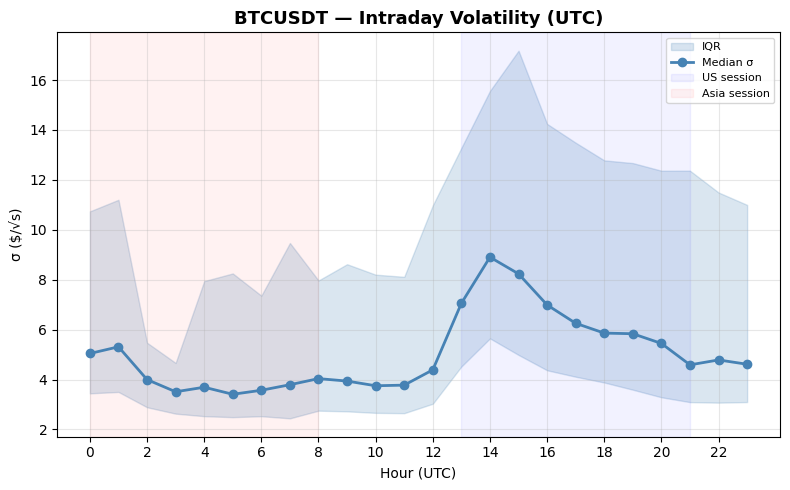

In [22]:
fig, axes = plt.subplots(1, len(SYMBOLS), figsize=(8*len(SYMBOLS), 5))
if len(SYMBOLS) == 1:
    axes = [axes]

for ax, symbol in zip(axes, SYMBOLS):
    hourly_sigma = {}

    # Use per-day data if available (more memory-efficient)
    if symbol in pipeline_results:
        daily_mids = pipeline_results[symbol]["all_mid"]
    elif symbol in mid_series:
        # Reconstruct daily splits from full parquet
        full  = mid_series[symbol]
        dates = full.index.normalize().unique()
        daily_mids = [full[full.index.normalize() == d] for d in dates]
    else:
        print(f"  {symbol}: no mid-price data available — skipping.")
        continue

    for mid_day in daily_mids:
        returns = mid_day.diff().dropna()
        for hour in range(24):
            r_h = returns[returns.index.hour == hour].values
            if len(r_h) > 60:
                hourly_sigma.setdefault(hour, []).append(float(np.std(r_h)))

    if not hourly_sigma:
        print(f"  {symbol}: not enough data for intraday pattern.")
        continue

    hours   = sorted(hourly_sigma)
    medians = [np.median(hourly_sigma[h]) for h in hours]
    p25     = [np.percentile(hourly_sigma[h], 25) for h in hours]
    p75     = [np.percentile(hourly_sigma[h], 75) for h in hours]

    ax.fill_between(hours, p25, p75, alpha=0.2, color="steelblue", label="IQR")
    ax.plot(hours, medians, "o-", color="steelblue", lw=2, ms=6, label="Median σ")
    ax.axvspan(13, 21, alpha=0.05, color="blue", label="US session")
    ax.axvspan(0,   8, alpha=0.05, color="red",  label="Asia session")
    ax.set_title(f"{symbol} — Intraday Volatility (UTC)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Hour (UTC)"); ax.set_ylabel("σ ($/√s)")
    ax.set_xticks(range(0, 24, 2)); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUT_DIR / "intraday_volatility.png"), dpi=150, bbox_inches="tight")
plt.show()

## Appendix B · Intensity Stability Over Time

Requires per-day delta arrays (checkpoint). Skipped if only parquet files are available.

  BTCUSDT: CV(A)=122.2%, CV(k)=306.7%, median R²=0.9744


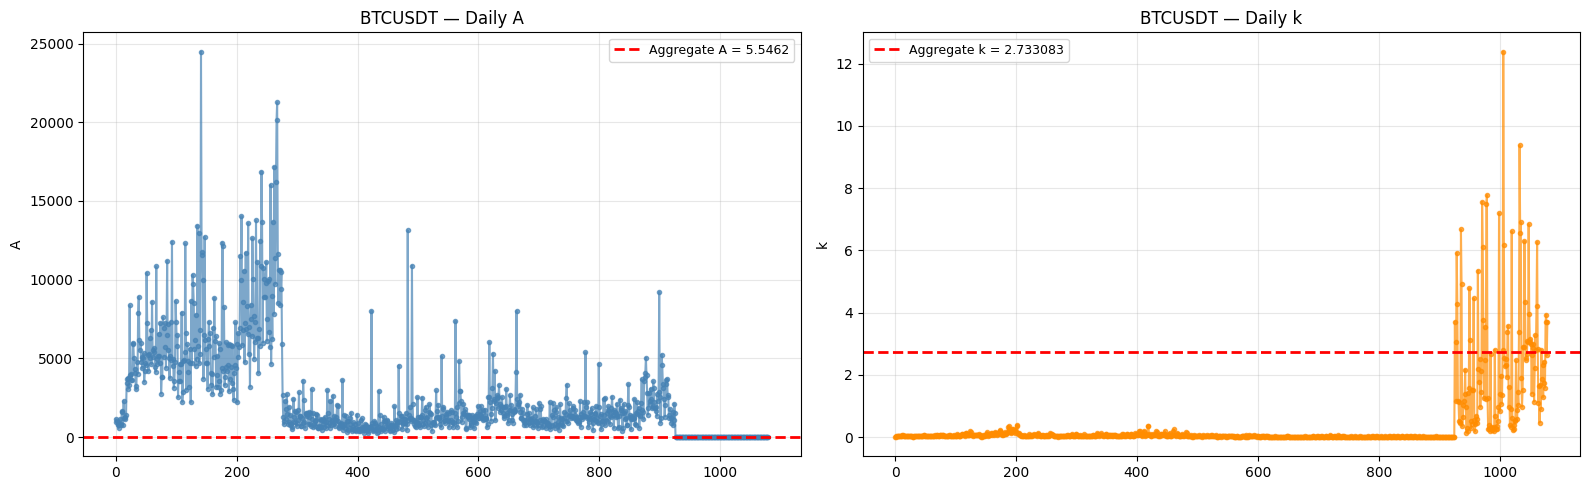

In [23]:
if not pipeline_results:
    print("⏭️  Appendix B requires per-day delta data (checkpoint.pkl).")
    print("   Not available when pipeline was skipped and checkpoint is missing.")
    print("   To regenerate: delete calibrated_params.json and re-run, or keep the checkpoint.")
else:
    fig, axes = plt.subplots(len(SYMBOLS), 2, figsize=(16, 5*len(SYMBOLS)))
    if len(SYMBOLS) == 1:
        axes = axes[np.newaxis, :]

    for row, symbol in enumerate(SYMBOLS):
        if symbol not in pipeline_results:
            continue
        res = pipeline_results[symbol]
        daily_A, daily_k, daily_r2 = [], [], []

        for deltas_day, stat in zip(res["all_deltas"], res["daily_stats"]):
            try:
                A_d, k_d, r2_d, *_ = fit_intensity(
                    deltas_day, stat["span_hours"]*3600, n_bins=30)
                daily_A.append(A_d); daily_k.append(k_d); daily_r2.append(r2_d)
            except Exception:
                continue

        x = range(len(daily_A))

        ax = axes[row, 0]
        ax.plot(x, daily_A, "o-", ms=3, alpha=0.7, color="steelblue")
        ax.axhline(calibrated[symbol]["A"], color="red", ls="--", lw=2,
                   label=f"Aggregate A = {calibrated[symbol]['A']:.4f}")
        ax.set_title(f"{symbol} — Daily A"); ax.set_ylabel("A"); ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

        ax = axes[row, 1]
        ax.plot(x, daily_k, "o-", ms=3, alpha=0.7, color="darkorange")
        ax.axhline(calibrated[symbol]["k"], color="red", ls="--", lw=2,
                   label=f"Aggregate k = {calibrated[symbol]['k']:.6f}")
        ax.set_title(f"{symbol} — Daily k"); ax.set_ylabel("k"); ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

        cv_A = np.std(daily_A)/np.mean(daily_A)*100
        cv_k = np.std(daily_k)/np.mean(daily_k)*100
        print(f"  {symbol}: CV(A)={cv_A:.1f}%, CV(k)={cv_k:.1f}%, "
              f"median R²={np.median(daily_r2):.4f}")

    plt.tight_layout()
    plt.savefig(str(OUT_DIR / "intensity_stability.png"), dpi=150, bbox_inches="tight")
    plt.show()

## Appendix D · Optimal Spread Surface (Real Parameters)

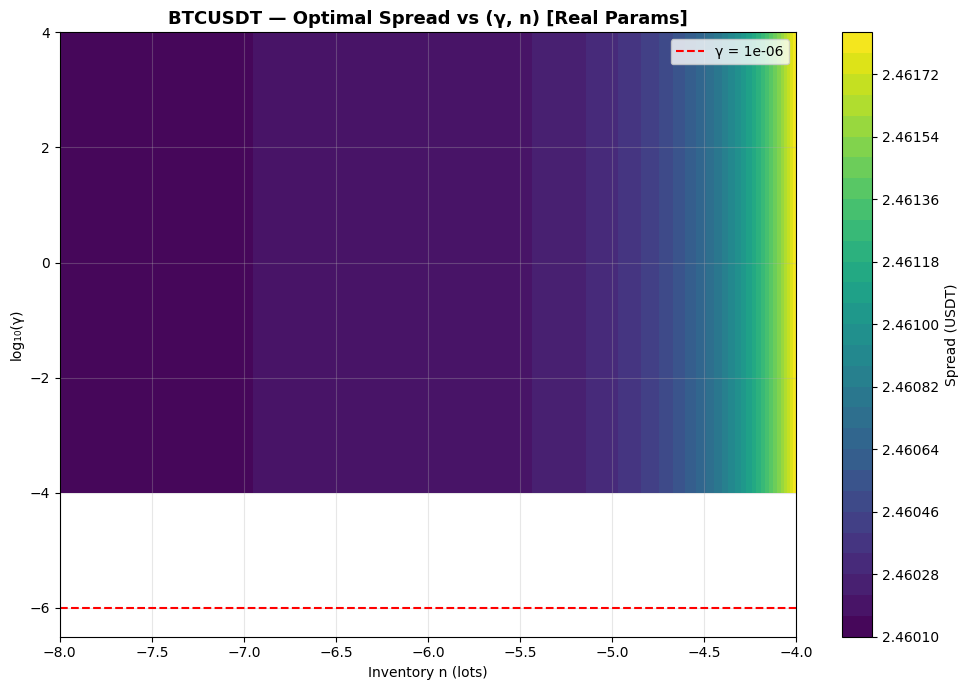

In [24]:
for symbol in SYMBOLS:
    if symbol not in calibrated:
        print(f"  {symbol}: no calibrated params — skipping.")
        continue

    p = calibrated[symbol]
    sigma, A, k, Delta, Q = p["sigma"], p["A"], p["k"], p["Delta"], p["Q"]
    gammas  = np.logspace(-8, -4, 50)
    n_range = np.arange(-Q, Q+1)
    spread_matrix = np.zeros((len(gammas), len(n_range)))

    for i, g in enumerate(gammas):
        xi = g * Delta
        d_s = (1/xi)*np.log(1+xi/k) if abs(xi)>1e-12 else 1/k
        C   = (xi/(1+xi/k))*(1/k)   if abs(xi)>1e-12 else 1/k**2
        om  = np.sqrt(g*sigma**2 / (2*A*Delta*k*C))
        for j, n in enumerate(n_range):
            db = d_s + om*(2*n+1)*Delta/2
            da = d_s - om*(2*n-1)*Delta/2
            spread_matrix[i,j] = max(db+da, 0)

    G, N = np.meshgrid(n_range, np.log10(gammas))
    fig, ax = plt.subplots(figsize=(10, 7))
    cf = ax.contourf(N, G, spread_matrix, levels=30, cmap="viridis")
    plt.colorbar(cf, ax=ax, label="Spread (USDT)")
    ax.set_title(f"{symbol} — Optimal Spread vs (γ, n) [Real Params]",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Inventory n (lots)"); ax.set_ylabel("log₁₀(γ)")
    ax.axhline(np.log10(GAMMA), color="red", ls="--", lw=1.5,
               label=f"γ = {GAMMA:.0e}")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(str(OUT_DIR / "spread_surface.png"), dpi=150, bbox_inches="tight")
    plt.show()

## Summary & Next Steps

### Outputs produced

| File | Description |
|------|-------------|
| `data/calibrated/calibrated_params.json` | σ, A, k, Δ, Q for each symbol + metadata |
| `data/calibrated/mid_prices_{SYM}.parquet` | 1-second VWAP mid-prices |
| `data/calibrated/daily_stats_{SYM}.csv` | Per-day summary statistics |
| `data/calibrated/checkpoints/` | Resume state (safe to delete after export) |
| `data/calibrated/*.png` | Diagnostic plots |

### Smart-skip behaviour

| State | What happens |
|-------|-------------|
| Both `.json` + `.parquet` exist | Skip download & processing; load + show plots |
| Only checkpoint exists | Resume processing from last saved day |
| Nothing exists | Full pipeline: download → process → export |
| `FORCE_RERUN = True` | Always run full pipeline regardless |

### Integration with Streamlit app

The app reads **only** `calibrated_params.json` and `mid_prices_{SYM}.parquet`.
Raw CSVs and checkpoints are never accessed by the dashboard.
After calibration, raw CSVs can be deleted to reclaim disk space.